<a href="https://colab.research.google.com/github/danikpretor/statistical-processing-of-measurement-results/blob/main/Wafet_Report_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Парсинг данных и содание DataFrame
* Загрузка данных: Читает данные о сопротивлении, Ueff и толщине из CSV-файлов для каждого
номера пластины (от 1 до 20).
* Обработка данных: объединяем данные по каждой пластине в отдельные DataFrame, затем переносим все данные в один большой DataFrame (factory_df). При чтении файлов фильтруем и удаляем нулевые символы и преобразуем данные в числа. Для облегчения датафрейма берём каждое 5-е значение (итоговая погрешность при 1, 5, 10 не меняется).
* Сводная таблица: Создаём сводную таблицу (summary_df) с основными статистиками (среднее, стандартное отклонение, среднее отклонение) для каждой пластины на основе заводских данных.

In [ ]:
'''
Подгружаем гугл диск
'''

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy import stats


def calculate_average_deviation(values):
    '''
    Функция расчёта среднего отклонения
    '''
    mean = np.mean(values)
    return np.mean(np.abs(values - mean))


def read_resistance_file(file_dir, name_file):
    '''
    Функция чтения CSV с очисткой
    '''
    file_path = os.path.join(file_dir, name_file)
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    cleaned_content = content.replace('\x00', '')
    all_values = cleaned_content.split(';')
    numeric_values = []
    for v in all_values:
        if v.strip():
            try:
                numeric_values.append(float(v))
            except ValueError:
                continue
    df_united = pd.DataFrame(numeric_values, columns=['value'])
    return df_united

'''
Читаем все данные с завода
'''

base_dir = '/content/drive/MyDrive/Colab Notebooks/Wafer 2'
wafer_numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
all_datasets = {}


for wafer_num in wafer_numbers:
    wafer_dir = os.path.join(base_dir, str(wafer_num))
    resistance_df = read_resistance_file(wafer_dir, 'resistance.csv')
    uef_v_df = read_resistance_file(wafer_dir, 'resistanceUeff.csv')
    thickness_files = ['thicknesscenter.csv', 'thicknessleft.csv', 'thicknessright.csv']
    thickness_data = [read_resistance_file(wafer_dir, f) for f in thickness_files]
    combined_thickness = pd.concat(thickness_data, ignore_index=True)

    resistance_values = resistance_df['value'].dropna().to_numpy()
    thickness_values = combined_thickness['value'].dropna().to_numpy()
    uef_v = uef_v_df['value'].dropna().to_numpy()

    min_len = min(len(resistance_values), len(thickness_values), len(uef_v))

    dataset = pd.DataFrame({
        'wafer': wafer_num,
        'resistance_ohm_cm': resistance_values[:min_len],
        'thickness_um': thickness_values[:min_len],
        'Uef_v': uef_v[:min_len]
    })
    all_datasets[wafer_num] = dataset

# Объединяем в один DataFrame
factory_df = pd.concat(all_datasets.values(), ignore_index=True)
factory_df = factory_df.set_index('wafer')

# ------------------------
# Сводная таблица по каждому номеру пластины
# ------------------------
summary_list = []
for wafer, df in all_datasets.items():
    summary = {
        'wafer': wafer,
        'mean_Uef_v': df['Uef_v'].mean(),
        'mean_thickness_um': df['thickness_um'].mean(),
        'std_thickness_um': df['thickness_um'].std(),
        'avg_deviation_thickness_um': calculate_average_deviation(df['thickness_um']),  # Среднее отклонение
        'mean_resistance': df['resistance_ohm_cm'].mean(),
        'std_resistance': df['resistance_ohm_cm'].std()
    }
    summary_list.append(summary)

summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.set_index('wafer')
# ------------------------
# Данные лаборатории
# ------------------------
lab_data = pd.DataFrame({
    'wafer': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'lab_thickness_um': [156.00, 155.96, 157.25, 154.27, 155.54, 155.08, 154.04, 130.79, 130.98, 130.68, 131.07, 131.21, 154.09, 141.31, 152.77, 152.78, 152.28, 152.18, 151.00, 155.19],
    'lab_resistivity_ohm_cm': [1.66, 1.69, 1.72, 1.30, 1.31, 1.31, 1.32, 2.09, 2.07, 1.41, 2.09, 2.12, 1.45, 1.24, 1.14, 1.20, 1.21, 1.21, 1.19, 1.18],
    'thickness_deviation': [12.72, 6.68, 6.51, 6.01, 4.54, 4.96, 6.49, 6.62, 4.83, 4.41, 3.62, 4.78, 5.99, 4.22, 6.66, 6.29, 4.03, 3.93, 4.43, 4.11]
})

lab_data = lab_data.set_index('wafer')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Wafer 2/3/thicknesscenter.csv'

In [ ]:
factory_df

,resistance_ohm_cm,thickness_um,Uef_v
wafer,,,
1,1.725,149.860,0.735
1,1.725,149.822,0.735
1,1.725,149.634,0.735
1,1.725,149.634,0.735
1,1.725,149.634,0.735
...,...,...,...
20,1.328,155.420,1.005
20,1.328,155.420,1.005
20,1.328,155.420,1.005


In [ ]:
lab_data

,lab_thickness_um,lab_resistivity_ohm_cm,thickness_deviation
wafer,,,
1,156.00,1.66,12.72
2,155.96,1.69,6.68
3,157.25,1.72,6.51
4,154.27,1.30,6.01
5,155.54,1.31,4.54
6,155.08,1.31,4.96
7,154.04,1.32,6.49
8,130.79,2.09,6.62
9,130.98,2.07,4.83


In [ ]:
summary_df

,mean_Uef_v,mean_thickness_um,std_thickness_um,avg_deviation_thickness_um,mean_resistance,std_resistance
wafer,,,,,,
1,0.770895,155.229066,2.020557,1.534801,1.646018,0.056969
2,0.747319,154.835339,1.105916,0.859837,1.694002,0.048607
3,0.741106,156.296829,1.196235,1.012283,1.699100,0.040505
4,0.986774,153.116392,1.092216,0.830419,1.259322,0.045348
5,0.975797,154.214901,1.158838,0.860644,1.285155,0.044863
6,0.966420,152.975990,1.294149,1.027210,1.278732,0.040431
7,0.507400,130.068243,1.226395,1.023532,2.082624,0.028728
8,0.505269,130.061194,1.294533,1.103928,2.088419,0.029634
9,0.511315,130.511338,0.783761,0.549808,2.113201,0.051657


## 2. Расчёт сопротивления пластин с помощью заводских коэффициентов

```python
K1 = 85.6
K2 = 0.008
```

In [ ]:
# ------------------------
# Перерасчёт сопротивлений
# ------------------------

# Коэффициенты для перерасчёта
K1 = 85.6
K2 = 0.008


def recalculate_resistance(row, K1, K2):
    '''
    Функция для пересчёта сопротивления
    '''
    Rs = K1 / (row['Uef_v'] - K2)
    resistance_ohm_cm = Rs * (row['thickness_um'] / 10000)  # Переводим толщину в см
    return resistance_ohm_cm

# Пересчитываем сопротивление для всех данных
factory_df['factory_resistance'] = factory_df.apply(
    lambda row: recalculate_resistance(row, K1, K2), axis=1
)

# Обновляем средние значения сопротивления для каждой пластины
mean_factory_resistance = factory_df.groupby('wafer')['factory_resistance'].mean()

comparison = pd.merge(summary_df, lab_data, on='wafer')

# Обновляем `comparison` новыми средними значениями сопротивления,
# только для тех пластин, которые есть в `comparison`
comparison = comparison.merge(
    mean_factory_resistance.rename('mean_factory_resistance').reset_index(),
    on='wafer',
    how='left'
)

# Пересчитываем разницу и относительную ошибку
comparison['d_factory_resistance'] = np.abs(
    comparison['mean_factory_resistance'] - comparison['lab_resistivity_ohm_cm']
)

comparison['rel_error_factory_resistance_%'] = (
    100 * comparison['d_factory_resistance'] / comparison['lab_resistivity_ohm_cm']
)

# Выводим обновлённое сравнение
print("=== Сравнение с лабораторией после пересчёта и фильтрации ===")
comparison_factory = comparison[['wafer','mean_factory_resistance', 'lab_resistivity_ohm_cm',
                                'd_factory_resistance', 'rel_error_factory_resistance_%']].copy()

# Выводим результат
print(comparison_factory)


# Делаем выводы, сравниваем значение с лабой. Лабораторные данные берем как истины (эталонные).


# Статистический анализ
print("\n=== Статистический анализ после пересчёта и фильтрации ===")
# T-тест сопротивления
t_factory_resistance, p_factory_resistance = stats.ttest_rel(
    comparison['mean_factory_resistance'], comparison['lab_resistivity_ohm_cm']
)

# F-тест сопротивления (отношение дисперсий)
std_factory_resistance = factory_df.groupby('wafer')['factory_resistance'].std()
F_factory_resistance = (std_factory_resistance.max() ** 2) / (std_factory_resistance.min() ** 2)
print(f"T-test сопротивления: t={t_factory_resistance:.3f}, p={p_factory_resistance:.3f}")
print(f"F-test сопротивления (отношение дисперсий): F={F_factory_resistance:.3f}")

# Интерпретация результатов
if p_factory_resistance > 0.05:
    print("✅ Различие в сопротивлении статистически незначимо (оборудование согласуется с лабораторией).")
else:
    print("⚠️ Сопротивление отличается значимо (p<0.05). Проверьте коэффициенты пересчёта Rs→ρ.")

# Дополнительная статистика
print(f"\n=== Дополнительная статистика ===")
print(f"Средняя относительная ошибка сопротивления: {comparison['rel_error_factory_resistance_%'].mean():.2f}%")


=== Сравнение с лабораторией после пересчёта и фильтрации ===
    wafer  mean_factory_resistance  lab_resistivity_ohm_cm  \
0       1                 1.743771                    1.66   
1       2                 1.794190                    1.69   
2       3                 1.826021                    1.72   
3       4                 1.340924                    1.30   
4       5                 1.365631                    1.31   
5       6                 1.367602                    1.31   
6       7                 2.229853                    1.32   
7       8                 2.239304                    2.09   
8       9                 2.220939                    2.07   
9      10                 1.505996                    1.41   
10     11                 2.200324                    2.09   
11     12                 2.262235                    2.12   
12     13                 1.536869                    1.45   
13     14                 1.262140                    1.24   
14     1

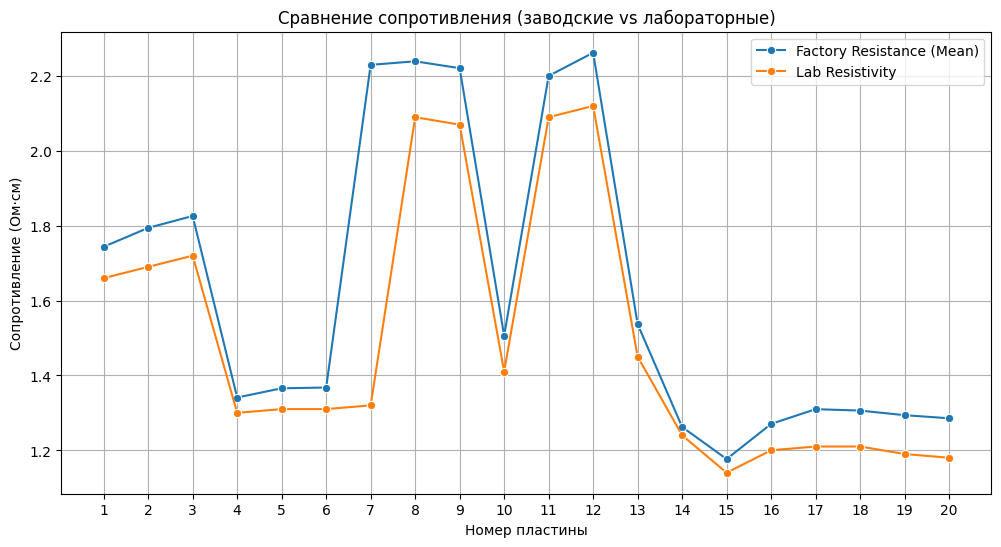

## 3. Перерасчтёт коэффициентов

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Средние значения Uef_v и толщины для каждой пластины
mean_U_eff = comparison['mean_Uef_v'].values
mean_Thk = comparison['mean_thickness_um'].values / 10000  # Переводим в сантиметры
lab_rho = comparison['lab_resistivity_ohm_cm'].values  # Лабораторные значения сопротивления

# Функция для расчёта сопротивления
def calculate_rho(params, U_eff, Thk):
    K1, K2 = params
    Rs = K1 / np.clip(U_eff - K2, 1e-9, None)
    rho = Rs * Thk
    return rho

# Функция ошибки для минимизации
#def error_function(params, U_eff, Thk, lab_rho):
#    rho = calculate_rho(params, U_eff, Thk)
#    return np.sum((rho - lab_rho) ** 2)

def error_function(params, U_eff, Thk, lab_rho):
    rho = calculate_rho(params, U_eff, Thk)
    relative_error = (rho - lab_rho) / lab_rho
    return np.mean(relative_error**2)

# Начальные значения коэффициентов
initial_params = [K1, K2]

# Минимизация ошибки
result = minimize(error_function, initial_params, args=(mean_U_eff, mean_Thk, lab_rho), method='L-BFGS-B')

# Оптимальные коэффициенты
K1_new, K2_new  = result.x

rho_opt = calculate_rho(result.x, mean_U_eff, mean_Thk)

print(f"Оптимальные коэффициенты: K1 = {K1_new:.3f}, K2 = {K2_new:.3f}")

# Проверка результата
rho_opt = calculate_rho(result.x, mean_U_eff, mean_Thk)
print("\nСравнение расчётных и лабораторных значений сопротивления:")
for i, (rho_calc, rho_lab) in enumerate(zip(rho_opt, lab_rho)):
    wafer_num = 16 + i
    print(f"Пластина {wafer_num}: расчётное = {rho_calc:.3f} Ом·см, лабораторное = {rho_lab:.3f} Ом·см")


Оптимальные коэффициенты: K1 = 98.960, K2 = -0.200

Сравнение расчётных и лабораторных значений сопротивления:
Пластина 16: расчётное = 1.582 Ом·см, лабораторное = 1.660 Ом·см
Пластина 17: расчётное = 1.617 Ом·см, лабораторное = 1.690 Ом·см
Пластина 18: расчётное = 1.643 Ом·см, лабораторное = 1.720 Ом·см
Пластина 19: расчётное = 1.277 Ом·см, лабораторное = 1.300 Ом·см
Пластина 20: расчётное = 1.298 Ом·см, лабораторное = 1.310 Ом·см
Пластина 21: расчётное = 1.298 Ом·см, лабораторное = 1.310 Ом·см
Пластина 22: расчётное = 1.819 Ом·см, лабораторное = 1.320 Ом·см
Пластина 23: расчётное = 1.825 Ом·см, лабораторное = 2.090 Ом·см
Пластина 24: расчётное = 1.815 Ом·см, лабораторное = 2.070 Ом·см
Пластина 25: расчётное = 1.358 Ом·см, лабораторное = 1.410 Ом·см
Пластина 26: расчётное = 1.804 Ом·см, лабораторное = 2.090 Ом·см
Пластина 27: расчётное = 1.840 Ом·см, лабораторное = 2.120 Ом·см
Пластина 28: расчётное = 1.429 Ом·см, лабораторное = 1.450 Ом·см
Пластина 29: расчётное = 1.192 Ом·см, лабора


## Расчёт сопротивления пластин с помощью новых коэффициентов
```python
K1_new = 79.799
K2_new = 0.014
```

In [ ]:
# ------------------------
# Расчёт сопротивления пластин с помощью новых коэффициентов
# ------------------------
#K1_new = 98.960
#K2_new = -0.200
#K1_new = 79.799
#K2_new = 0.014

factory_df['factory_resistance_new_coeffs'] = factory_df.apply(
    lambda row: recalculate_resistance(row, K1_new, K2_new), axis=1
)

# Обновляем средние значения сопротивления для каждой пластины с новыми коэффициентами
mean_factory_resistance_new_coeffs = factory_df.groupby('wafer')['factory_resistance_new_coeffs'].mean()

# Сравнение с лабораторией с использованием новых коэффициентов
comparison_new_coeffs = pd.merge(summary_df, lab_data, on='wafer')

# Удаляем старые столбцы сравнения, если они существуют
comparison_new_coeffs = comparison_new_coeffs.drop(columns=[
    col for col in comparison_new_coeffs.columns if col.startswith(('recalculated_mean_resistance', 'd_recalculated_resistance', 'rel_error_recalculated_resistance'))
], errors='ignore')

# Добавляем новые средние значения сопротивления к сравнению
comparison_new_coeffs = pd.merge(
    comparison_new_coeffs,
    mean_factory_resistance_new_coeffs.rename('recalculated_mean_resistance_new_coeffs'),
    on='wafer',
    how='left'
)

# Пересчитываем разницу и относительную ошибку с новыми коэффициентами
comparison_new_coeffs['d_recalculated_resistance_new_coeffs'] = np.abs(
    comparison_new_coeffs['recalculated_mean_resistance_new_coeffs'] - comparison_new_coeffs['lab_resistivity_ohm_cm']
)

comparison_new_coeffs['rel_error_recalculated_resistance_new_coeffs_%'] = (
    100 * comparison_new_coeffs['d_recalculated_resistance_new_coeffs'] / comparison_new_coeffs['lab_resistivity_ohm_cm']
)

# Выводим обновлённое сравнение с новыми коэффициентами
print("=== Сравнение с лабораторией после пересчёта с новыми коэффициентами ===")
# Создаем DataFrame для вывода, включая индекс 'wafer'
comparison_recalculated_new_coeffs = pd.DataFrame(
    comparison_new_coeffs[['recalculated_mean_resistance_new_coeffs', 'lab_resistivity_ohm_cm', 'd_recalculated_resistance_new_coeffs', 'rel_error_recalculated_resistance_new_coeffs_%']]
)

# Выводим результат
print(comparison_recalculated_new_coeffs)

# ------------------------
# Статистический анализ с новыми коэффициентами
# ------------------------
print("\n=== Статистический анализ после пересчёта с новыми коэффициентами ===")

# T-тест сопротивления с новыми коэффициентами
t_recalculated_res_new, p_recalculated_res_new = stats.ttest_rel(
    comparison_new_coeffs['recalculated_mean_resistance_new_coeffs'], comparison_new_coeffs['lab_resistivity_ohm_cm']
)

print(f"T-test сопротивления (новые коэффициенты): t={t_recalculated_res_new:.3f}, p={p_recalculated_res_new:.3f}")


# Интерпретация результатов с новыми коэффициентами
if p_recalculated_res_new > 0.05:
    print("✅ Различие в сопротивлении статистически незначимо (оборудование согласуется с лабораторией при новых коэффициентах).")
else:
    print("⚠️ Сопротивление отличается значимо (p<0.05) при новых коэффициентах. Проверьте коэффициенты пересчёта Rs→ρ.")

# Дополнительная статистика с новыми коэффициентами
print(f"\n=== Дополнительная статистика (новые коэффициенты) ===")
print(f"Средняя относительная ошибка сопротивления: {comparison_new_coeffs['rel_error_recalculated_resistance_new_coeffs_%'].mean():.2f}%")

=== Сравнение с лабораторией после пересчёта с новыми коэффициентами ===
       recalculated_mean_resistance_new_coeffs  lab_resistivity_ohm_cm  \
wafer                                                                    
1                                     1.583124                    1.66   
2                                     1.618050                    1.69   
3                                     1.643855                    1.72   
4                                     1.277830                    1.30   
5                                     1.298841                    1.31   
6                                     1.298556                    1.31   
7                                     1.819393                    1.32   
8                                     1.824796                    2.09   
9                                     1.815913                    2.07   
10                                    1.358619                    1.41   
11                                    1

In [ ]:
# ------------------------
# Расчёт сопротивления пластин с помощью новых коэффициентов
# ------------------------

K1_new = 90.553
K2_new = -0.098

factory_df['factory_resistance_new_coeffs'] = factory_df.apply(
    lambda row: recalculate_resistance(row, K1_new, K2_new), axis=1
)

# Обновляем средние значения сопротивления для каждой пластины с новыми коэффициентами
mean_factory_resistance_new_coeffs = factory_df.groupby('wafer')['factory_resistance_new_coeffs'].mean()

# Сравнение с лабораторией с использованием новых коэффициентов
comparison_new_coeffs = pd.merge(summary_df, lab_data, on='wafer')

# Удаляем старые столбцы сравнения, если они существуют
comparison_new_coeffs = comparison_new_coeffs.drop(columns=[
    col for col in comparison_new_coeffs.columns if col.startswith(('recalculated_mean_resistance', 'd_recalculated_resistance', 'rel_error_recalculated_resistance'))
], errors='ignore')

# Добавляем новые средние значения сопротивления к сравнению
comparison_new_coeffs = pd.merge(
    comparison_new_coeffs,
    mean_factory_resistance_new_coeffs.rename('recalculated_mean_resistance_new_coeffs'),
    on='wafer',
    how='left'
)

# Пересчитываем разницу и относительную ошибку с новыми коэффициентами
comparison_new_coeffs['d_recalculated_resistance_new_coeffs'] = np.abs(
    comparison_new_coeffs['recalculated_mean_resistance_new_coeffs'] - comparison_new_coeffs['lab_resistivity_ohm_cm']
)

comparison_new_coeffs['rel_error_recalculated_resistance_new_coeffs_%'] = (
    100 * comparison_new_coeffs['d_recalculated_resistance_new_coeffs'] / comparison_new_coeffs['lab_resistivity_ohm_cm']
)

# Выводим обновлённое сравнение с новыми коэффициентами
print("=== Сравнение с лабораторией после пересчёта с новыми коэффициентами ===")
# Создаем DataFrame для вывода, включая индекс 'wafer'
comparison_recalculated_new_coeffs = pd.DataFrame(
    comparison_new_coeffs[['recalculated_mean_resistance_new_coeffs', 'lab_resistivity_ohm_cm', 'd_recalculated_resistance_new_coeffs', 'rel_error_recalculated_resistance_new_coeffs_%']]
)

# Выводим результат
print(comparison_recalculated_new_coeffs)

# ------------------------
# Статистический анализ с новыми коэффициентами
# ------------------------
print("\n=== Статистический анализ после пересчёта с новыми коэффициентами ===")

# T-тест сопротивления с новыми коэффициентами
t_recalculated_res_new, p_recalculated_res_new = stats.ttest_rel(
    comparison_new_coeffs['recalculated_mean_resistance_new_coeffs'], comparison_new_coeffs['lab_resistivity_ohm_cm']
)

print(f"T-test сопротивления (новые коэффициенты): t={t_recalculated_res_new:.3f}, p={p_recalculated_res_new:.3f}")


# Интерпретация результатов с новыми коэффициентами
if p_recalculated_res_new > 0.05:
    print("✅ Различие в сопротивлении статистически незначимо (оборудование согласуется с лабораторией при новых коэффициентах).")
else:
    print("⚠️ Сопротивление отличается значимо (p<0.05) при новых коэффициентах. Проверьте коэффициенты пересчёта Rs→ρ.")

# Дополнительная статистика с новыми коэффициентами
print(f"\n=== Дополнительная статистика (новые коэффициенты) ===")
print(f"Средняя относительная ошибка сопротивления: {comparison_new_coeffs['rel_error_recalculated_resistance_new_coeffs_%'].mean():.2f}%")

=== Сравнение с лабораторией после пересчёта с новыми коэффициентами ===
       recalculated_mean_resistance_new_coeffs  lab_resistivity_ohm_cm  \
wafer                                                                    
1                                     1.619195                    1.66   
2                                     1.659684                    1.69   
3                                     1.687434                    1.72   
4                                     1.279587                    1.30   
5                                     1.301749                    1.31   
6                                     1.302422                    1.31   
7                                     1.945744                    1.32   
8                                     1.952521                    2.09   
9                                     1.940363                    2.07   
10                                    1.393369                    1.41   
11                                    1